### Model rank of HBA - LOOIC and MAP - BIC

In [ ]:
import pandas as pd
model_comp = pd.read_csv("./HBA_results/model_comparison.csv", index_col=0)
looic_order = model_comp.sort_values("looic").index
bic_order = model_comp.sort_values("map_BIC").index
print(f"LOOIC order: {looic_order}")
print(f"BIC order: {bic_order}")

### deep look into the "gamma short"

(array([ 0.,  0., 93.,  2.,  0.,  0.,  1.,  0.,  0.,  1.,  0.,  0.,  0.,
         0.,  2.,  0.,  0.,  0.,  0.,  0.,  0.]),
 array([-0.1 , -0.05,  0.  ,  0.05,  0.1 ,  0.15,  0.2 ,  0.25,  0.3 ,
         0.35,  0.4 ,  0.45,  0.5 ,  0.55,  0.6 ,  0.65,  0.7 ,  0.75,
         0.8 ,  0.85,  0.9 ,  0.95]),
 <BarContainer object of 21 artists>)

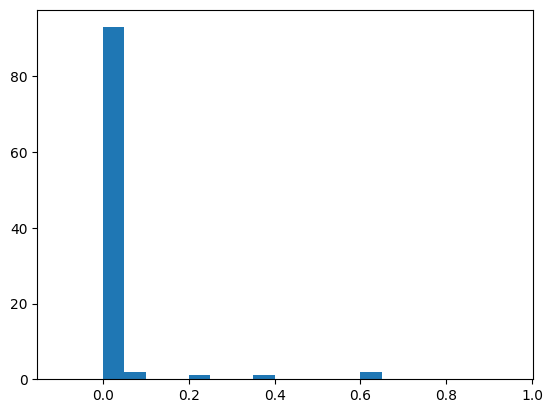

In [38]:
import arviz as az
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
idata = az.from_netcdf("HBA_model/UCB_beta_epsilon_eta/100/idata/model_fit.nc")
map_est = pd.read_csv("MAP_results/parameter_estimates/UCB_beta_epsilon_eta.csv", index_col=0).iloc[:100, ]
gamma_short_mean = idata.posterior["gamma"].sel({"gamma_dim_0": 0}).values.mean(axis=(0, 1))
plt.hist(map_est["gamma_short"], bins = np.arange(-0.1, 1, 0.05))
# plt.hist(gamma_short_mean, bins = np.arange(-0.1, 1, 0.05))